# Hospital Data Analysis Dashboard (Q1-Q10)

This notebook loads `hospital_data.csv`, performs light cleaning, and answers all questions with visualizations:

- Q1: Average consultation fee by department (bar plot)
- Q2: Patient visits by department and gender (count plot)
- Q3: Age distribution (histogram)
- Q4: Wait-time spread by department (box plot)
- Q5: Satisfaction distribution by insurance (violin plot)
- Q6: Individual wait times by city and gender (strip plot)
- Q7: Age vs systolic blood pressure (scatter plot)
- Q8: Numeric correlation matrix (heatmap)
- Q9: Monthly average wait time trend (line plot)
- Q10: Combined 4-panel dashboard


Q1 - Highest average consultation fee department: Cardiology (GHS 220.00)


/var/folders/h_/5wb7r2f91dd6t40nqk5l9djm0000gn/T/ipykernel_23040/3842871996.py:72: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce', dayfirst=True)


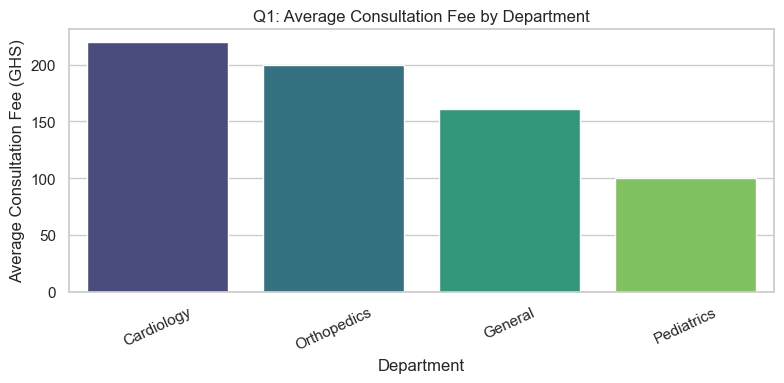


Q2 - Patient visits by department and gender
gender       Female  Male
department               
Cardiology        1     9
General           7     2
Orthopedics       1     7
Pediatrics        8     0


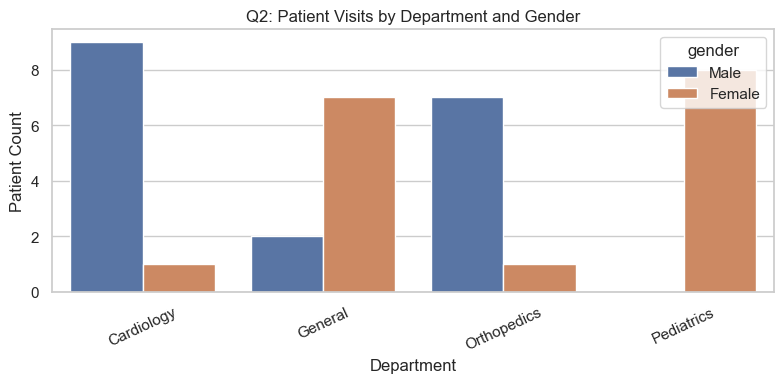


Q3 - Age group counts
age
Middle-aged (30-49)    13
Young (<=29)            8
Older (50+)             8
Name: count, dtype: int64


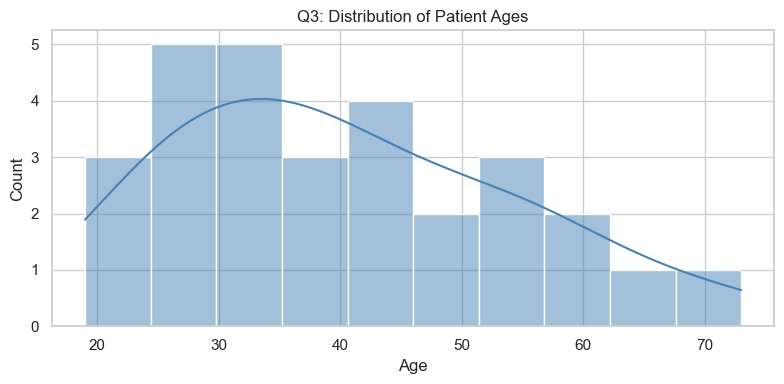


Q4 - Outliers by department (IQR rule)
             outliers
department           
Cardiology          1
General             0
Orthopedics         0
Pediatrics          1


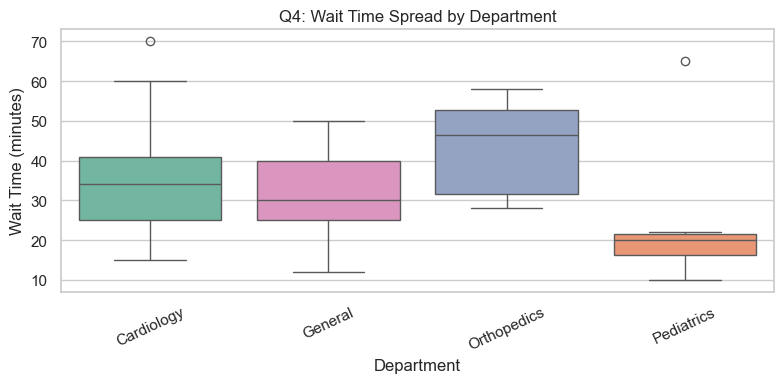


Q5 - Mean satisfaction by insurance status
insurance
Insured      7.77
Uninsured    7.33
Name: satisfaction_score, dtype: float64


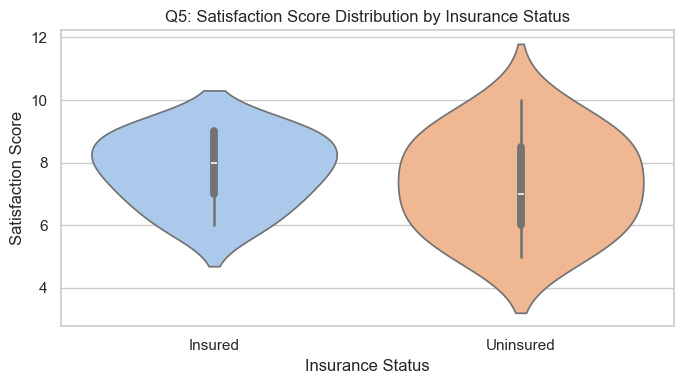

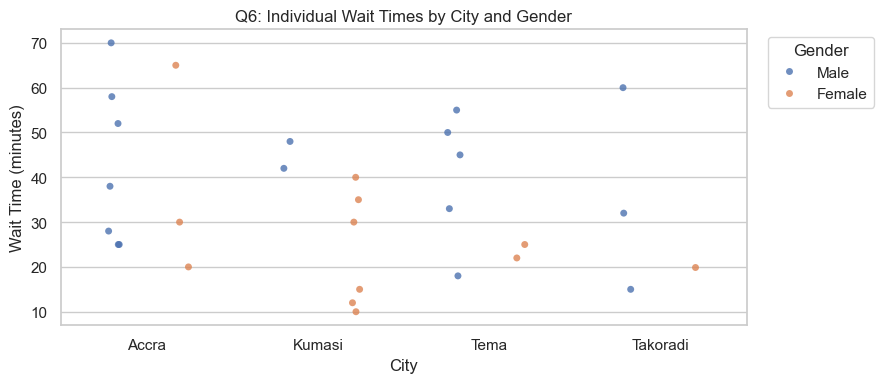

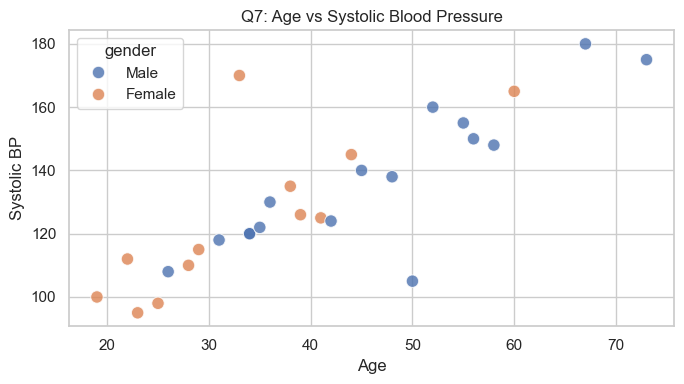


Q8 - Strongest correlations
systolic_bp         diastolic_bp          0.990
age                 wait_time_min         0.968
weight_kg_num       diastolic_bp          0.915
                    systolic_bp           0.910
satisfaction_score  wait_time_min        -0.876
age                 satisfaction_score   -0.842
dtype: float64


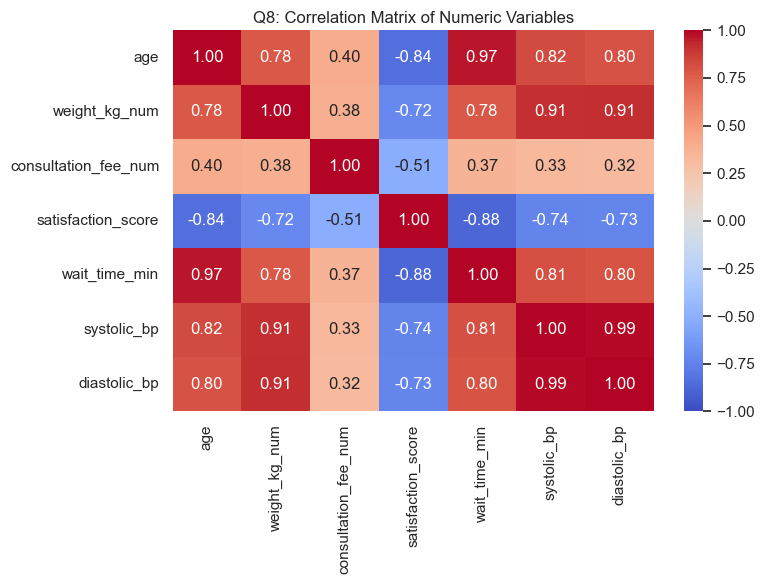


Q9 - Monthly average wait times (Jan-Aug 2025)
2025-01-31    31.0
2025-02-28    35.5
2025-03-31    48.0
2025-04-30    41.5
2025-05-31     NaN
2025-06-30     NaN
2025-07-31     NaN
2025-08-31     NaN
Freq: ME, Name: wait_time_min, dtype: float64


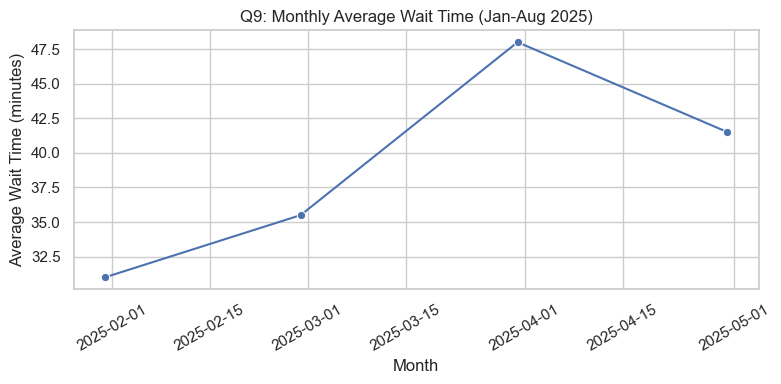

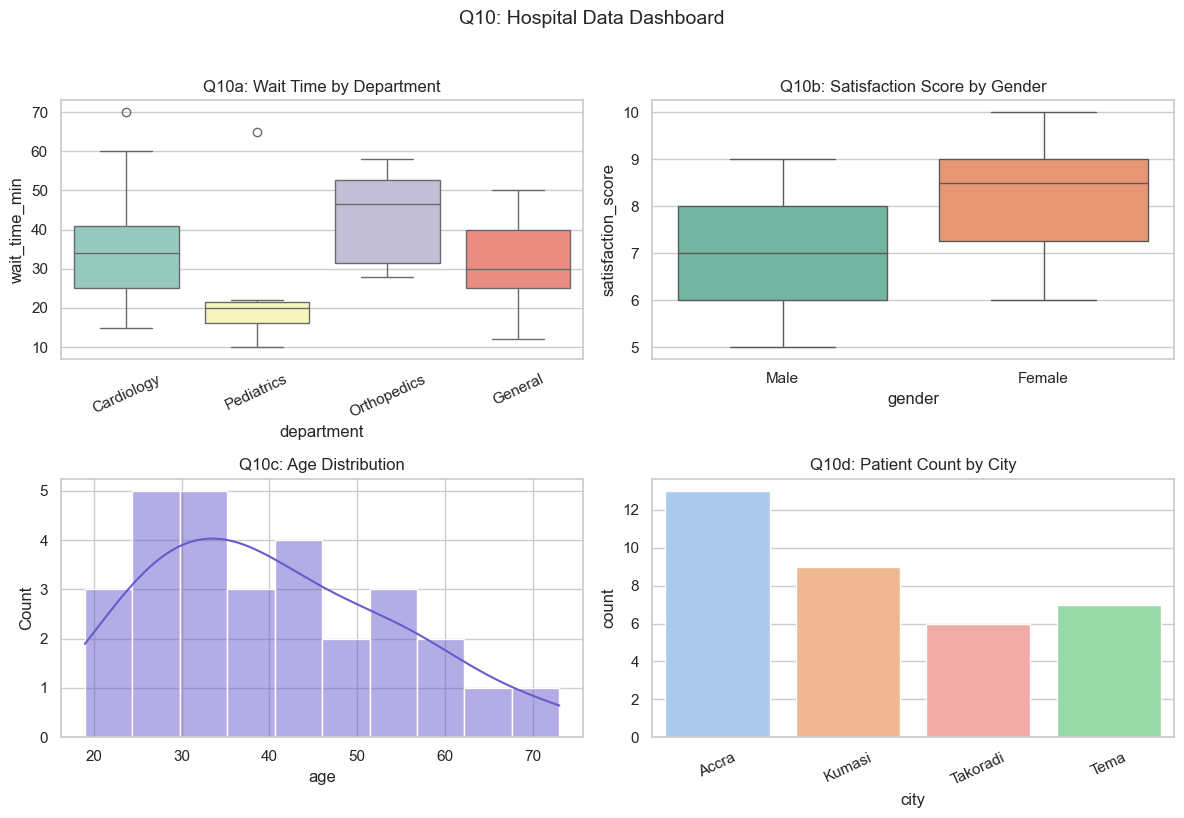

In [1]:
import sys
import subprocess
import importlib


def ensure_package(module_name, pip_name=None):
    if pip_name is None:
        pip_name = module_name
    try:
        return importlib.import_module(module_name)
    except ModuleNotFoundError:
        # Some kernels (especially fresh venv/uv envs) do not have pip bootstrapped.
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', '--version'])
        except subprocess.CalledProcessError:
            subprocess.check_call([sys.executable, '-m', 'ensurepip', '--upgrade'])

        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name])
        return importlib.import_module(module_name)


pd = ensure_package('pandas')
np = ensure_package('numpy')
plt = ensure_package('matplotlib.pyplot', 'matplotlib')
sns = ensure_package('seaborn')

# -----------------------------
# Load and clean data
# -----------------------------
df = pd.read_csv('hospital_data.csv')

for c in ['department', 'city', 'insurance', 'gender', 'blood_pressure', 'consultation_fee', 'weight_kg', 'visit_date']:
    df[c] = df[c].astype(str).str.strip()

# Normalize gender

def norm_gender(x):
    x = x.lower()
    if x in ['male', 'm']:
        return 'Male'
    if x in ['female', 'f']:
        return 'Female'
    return np.nan

df['gender'] = df['gender'].apply(norm_gender)

# Normalize categorical values
df['department'] = df['department'].str.title()
df['city'] = df['city'].str.title()
df['insurance'] = df['insurance'].str.lower().map({'yes': 'Insured', 'no': 'Uninsured'})

# Numeric conversions
for c in ['age', 'wait_time_min', 'satisfaction_score']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['consultation_fee_num'] = pd.to_numeric(
    df['consultation_fee'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

df['weight_kg_num'] = pd.to_numeric(
    df['weight_kg'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
)

bp = df['blood_pressure'].replace('N/A', np.nan)
bp_split = bp.str.extract(r'(?P<systolic>\d+)\s*/\s*(?P<diastolic>\d+)')
df['systolic_bp'] = pd.to_numeric(bp_split['systolic'], errors='coerce')
df['diastolic_bp'] = pd.to_numeric(bp_split['diastolic'], errors='coerce')

# Mixed date formats in source data
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce', dayfirst=True)

sns.set_theme(style='whitegrid')

# -----------------------------
# Q1: Highest average consultation fee by department
# -----------------------------
q1 = df.groupby('department')['consultation_fee_num'].mean().sort_values(ascending=False)
print('Q1 - Highest average consultation fee department:', q1.index[0], f"(GHS {q1.iloc[0]:.2f})")

a = plt.figure(figsize=(8, 4))
sns.barplot(x=q1.index, y=q1.values, hue=q1.index, dodge=False, legend=False, palette='viridis')
plt.title('Q1: Average Consultation Fee by Department')
plt.xlabel('Department')
plt.ylabel('Average Consultation Fee (GHS)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# -----------------------------
# Q2: Patient count by department and gender
# -----------------------------
print('\nQ2 - Patient visits by department and gender')
print(pd.crosstab(df['department'], df['gender']))

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='department', hue='gender', order=sorted(df['department'].dropna().unique()))
plt.title('Q2: Patient Visits by Department and Gender')
plt.xlabel('Department')
plt.ylabel('Patient Count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# -----------------------------
# Q3: Age distribution
# -----------------------------
age_bins = pd.cut(df['age'], bins=[0, 29, 49, 120], labels=['Young (<=29)', 'Middle-aged (30-49)', 'Older (50+)'])
print('\nQ3 - Age group counts')
print(age_bins.value_counts())

plt.figure(figsize=(8, 4))
sns.histplot(df['age'].dropna(), bins=10, kde=True, color='steelblue')
plt.title('Q3: Distribution of Patient Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# -----------------------------
# Q4: Wait-time spread and outliers by department
# -----------------------------
print('\nQ4 - Outliers by department (IQR rule)')
outliers = []
for dep, grp in df[['department', 'wait_time_min']].dropna().groupby('department'):
    q1v = grp['wait_time_min'].quantile(0.25)
    q3v = grp['wait_time_min'].quantile(0.75)
    iqr = q3v - q1v
    lo = q1v - 1.5 * iqr
    hi = q3v + 1.5 * iqr
    out_n = ((grp['wait_time_min'] < lo) | (grp['wait_time_min'] > hi)).sum()
    outliers.append((dep, int(out_n)))
print(pd.DataFrame(outliers, columns=['department', 'outliers']).set_index('department'))

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='department', y='wait_time_min', order=sorted(df['department'].dropna().unique()), hue='department', legend=False, palette='Set2')
plt.title('Q4: Wait Time Spread by Department')
plt.xlabel('Department')
plt.ylabel('Wait Time (minutes)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# -----------------------------
# Q5: Satisfaction by insurance status
# -----------------------------
print('\nQ5 - Mean satisfaction by insurance status')
print(df.groupby('insurance')['satisfaction_score'].mean().round(2))

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x='insurance', y='satisfaction_score', hue='insurance', dodge=False, legend=False, palette='pastel')
plt.title('Q5: Satisfaction Score Distribution by Insurance Status')
plt.xlabel('Insurance Status')
plt.ylabel('Satisfaction Score')
plt.tight_layout()
plt.show()

# -----------------------------
# Q6: Individual wait times by city and gender
# -----------------------------
plt.figure(figsize=(9, 4))
sns.stripplot(data=df, x='city', y='wait_time_min', hue='gender', dodge=True, jitter=True, alpha=0.8)
plt.title('Q6: Individual Wait Times by City and Gender')
plt.xlabel('City')
plt.ylabel('Wait Time (minutes)')
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# -----------------------------
# Q7: Relationship between age and systolic BP
# -----------------------------
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='age', y='systolic_bp', hue='gender', s=80, alpha=0.8)
plt.title('Q7: Age vs Systolic Blood Pressure')
plt.xlabel('Age')
plt.ylabel('Systolic BP')
plt.tight_layout()
plt.show()

# -----------------------------
# Q8: Correlation matrix of numeric variables
# -----------------------------
num_df = df[['age', 'weight_kg_num', 'consultation_fee_num', 'satisfaction_score', 'wait_time_min', 'systolic_bp', 'diastolic_bp']]
corr = num_df.corr(numeric_only=True)

print('\nQ8 - Strongest correlations')
strong_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=lambda s: s.abs(), ascending=False)
print(strong_corr.head(6).round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Q8: Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

# -----------------------------
# Q9: Monthly average wait-time trend (Jan-Aug 2025)
# -----------------------------
monthly = (
    df.dropna(subset=['visit_date'])
      .query("visit_date >= '2025-01-01' and visit_date <= '2025-08-31'")
      .set_index('visit_date')
      .resample('ME')['wait_time_min']
      .mean()
)
idx = pd.period_range('2025-01', '2025-08', freq='M').to_timestamp('M')
monthly = monthly.reindex(idx)

print('\nQ9 - Monthly average wait times (Jan-Aug 2025)')
print(monthly.round(2))

plt.figure(figsize=(8, 4))
sns.lineplot(x=monthly.index, y=monthly.values, marker='o')
plt.title('Q9: Monthly Average Wait Time (Jan-Aug 2025)')
plt.xlabel('Month')
plt.ylabel('Average Wait Time (minutes)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# -----------------------------
# Q10: Combined 4-panel dashboard
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='department', y='wait_time_min', ax=axes[0, 0], hue='department', legend=False, palette='Set3')
axes[0, 0].set_title('Q10a: Wait Time by Department')
axes[0, 0].tick_params(axis='x', rotation=25)

sns.boxplot(data=df, x='gender', y='satisfaction_score', ax=axes[0, 1], hue='gender', legend=False, palette='Set2')
axes[0, 1].set_title('Q10b: Satisfaction Score by Gender')

sns.histplot(df['age'].dropna(), bins=10, kde=True, ax=axes[1, 0], color='slateblue')
axes[1, 0].set_title('Q10c: Age Distribution')

sns.countplot(data=df, x='city', ax=axes[1, 1], hue='city', legend=False, palette='pastel', order=sorted(df['city'].dropna().unique()))
axes[1, 1].set_title('Q10d: Patient Count by City')
axes[1, 1].tick_params(axis='x', rotation=25)

fig.suptitle('Q10: Hospital Data Dashboard', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
